In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and Dataset Overview

In this step, we load the dataset and perform an initial inspection to understand its structure and contents.  
We preview the first few rows of the dataset, check the dataset shape, and examine the data types and missing values.

- **Data Loading:** The dataset is loaded into a Pandas DataFrame.

- **Data Preview:** The `head()` function is used to display the first few rows of the dataset.

- **Dataset Shape:** Shows the number of rows and columns present in the dataset.

- **Dataset Information:** The `info()` function provides details about column data types and non-null values.

In [9]:
df = pd.read_csv(r"C:\Users\ADMIN\Downloads\NIFTY50_all.csv\NIFTY50_all.csv")

In [10]:
df.shape

(235192, 15)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235192 entries, 0 to 235191
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Date                235192 non-null  str    
 1   Symbol              235192 non-null  str    
 2   Series              235192 non-null  str    
 3   Prev Close          235192 non-null  float64
 4   Open                235192 non-null  float64
 5   High                235192 non-null  float64
 6   Low                 235192 non-null  float64
 7   Last                235192 non-null  float64
 8   Close               235192 non-null  float64
 9   VWAP                235192 non-null  float64
 10  Volume              235192 non-null  int64  
 11  Turnover            235192 non-null  float64
 12  Trades              120344 non-null  float64
 13  Deliverable Volume  219115 non-null  float64
 14  %Deliverble         219115 non-null  float64
dtypes: float64(11), int64(1), str(3)
memory usage

In [12]:
df['Date'] = pd.to_datetime(df['Date'])

In [13]:
df.sample(10)

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
227853,2013-02-07,WIPRO,EQ,405.65,403.00,407.60,401.00,405.95,405.70,405.27,478637,1.939751e+13,13459.0,254144.0,0.5310
175664,2016-06-23,SBIN,EQ,212.90,213.00,218.00,212.75,217.80,217.55,215.84,20666649,4.460588e+14,125144.0,6492054.0,0.3141
194606,2008-07-21,TATASTEEL,EQ,592.55,615.00,615.00,581.50,598.00,599.05,600.83,1998595,1.200808e+14,NaN,246407.0,0.1233
136359,2019-08-23,KOTAKBANK,EQ,1478.25,1479.90,1487.00,1446.10,1469.45,1470.20,1464.43,3615793,5.295078e+14,127744.0,1652501.0,0.4570
91507,2002-02-14,HINDALC0,EQ,740.25,744.95,755.00,744.00,752.00,752.05,751.88,77010,5.790265e+12,NaN,68465.0,0.8890
140876,2020-12-24,LT,EQ,1264.80,1275.00,1281.00,1253.50,1262.80,1262.20,1265.23,3277840,4.147208e+14,81994.0,1012481.0,0.3089
150740,2010-03-17,NESTLEIND,EQ,2672.35,2690.00,2690.00,2655.00,2681.00,2678.55,2674.02,2149,5.746471e+11,NaN,1430.0,0.6654
99189,2011-08-19,HINDUNILVR,EQ,316.80,313.55,319.40,312.70,315.00,315.70,315.86,1724375,5.446600e+13,12382.0,920332.0,0.5337
60850,2006-10-12,GAIL,EQ,253.85,254.00,260.65,253.00,259.80,259.55,258.09,641585,1.655887e+13,NaN,426854.0,0.6653
94901,2015-09-28,HINDALCO,EQ,71.40,71.90,73.00,70.25,70.50,70.55,71.30,6132965,4.372675e+13,27192.0,1660740.0,0.2708


In [14]:
df['Symbol'].unique()

<StringArray>
['MUNDRAPORT', 'ADANIPORTS', 'ASIANPAINT',    'UTIBANK',   'AXISBANK',
 'BAJAJ-AUTO', 'BAJAJFINSV', 'BAJAUTOFIN', 'BAJFINANCE',     'BHARTI',
 'BHARTIARTL',       'BPCL',  'BRITANNIA',      'CIPLA',  'COALINDIA',
    'DRREDDY',  'EICHERMOT',       'GAIL',     'GRASIM',    'HCLTECH',
       'HDFC',   'HDFCBANK',  'HEROHONDA', 'HEROMOTOCO',   'HINDALC0',
   'HINDALCO',  'HINDLEVER', 'HINDUNILVR',  'ICICIBANK', 'INDUSINDBK',
 'INFOSYSTCH',       'INFY',        'IOC',        'ITC',     'JSWSTL',
   'JSWSTEEL',   'KOTAKMAH',  'KOTAKBANK',         'LT',        'M&M',
     'MARUTI',  'NESTLEIND',       'NTPC',       'ONGC',  'POWERGRID',
   'RELIANCE',       'SBIN',   'SHREECEM',  'SUNPHARMA',      'TELCO',
 'TATAMOTORS',      'TISCO',  'TATASTEEL',        'TCS',      'TECHM',
      'TITAN', 'ULTRACEMCO',    'UNIPHOS',        'UPL',    'SESAGOA',
       'SSLT',       'VEDL',      'WIPRO',    'ZEETELE',       'ZEEL']
Length: 65, dtype: str

In [15]:
df.corr(numeric_only=True)['Close']

Prev Close            0.999518
Open                  0.999761
High                  0.999892
Low                   0.999878
Last                  0.999991
Close                 1.000000
VWAP                  0.999963
Volume               -0.118705
Turnover              0.053106
Trades               -0.149751
Deliverable Volume   -0.133042
%Deliverble          -0.009362
Name: Close, dtype: float64

In [16]:
columns_to_drop = ['Series', 'Prev Close', 'Last', 'Turnover']
df = df.drop(columns=columns_to_drop)

In [17]:
df = df.drop(columns=[
'Trades',
'%Deliverble'
])

In [18]:
df = df.sort_values(['Symbol', 'Date'])

In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 235192 entries, 1023 to 231681
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Date                235192 non-null  datetime64[us]
 1   Symbol              235192 non-null  str           
 2   Open                235192 non-null  float64       
 3   High                235192 non-null  float64       
 4   Low                 235192 non-null  float64       
 5   Close               235192 non-null  float64       
 6   VWAP                235192 non-null  float64       
 7   Volume              235192 non-null  int64         
 8   Deliverable Volume  219115 non-null  float64       
dtypes: datetime64[us](1), float64(6), int64(1), str(1)
memory usage: 17.9 MB


In [20]:
df.describe()

,Date,Open,High,Low,Close,VWAP,Volume,Deliverable Volume
count,235192,235192.000000,235192.000000,235192.000000,235192.000000,235192.00000,2.351920e+05,2.191150e+05
mean,2011-05-22 13:18:08.975815,1267.759708,1286.581440,1247.488465,1266.554351,1267.13230,3.045903e+06,1.315098e+06
min,2000-01-03 00:00:00,8.500000,9.750000,8.500000,9.150000,9.21000,3.000000e+00,5.000000e+00
25%,2006-07-03 00:00:00,275.000000,279.500000,269.600000,274.350000,274.69750,2.190095e+05,1.253830e+05
50%,2011-08-19 00:00:00,567.025000,576.900000,556.500000,566.700000,566.94000,1.010938e+06,5.017560e+05
75%,2016-06-24 00:00:00,1243.312500,1263.000000,1221.650000,1242.400000,1242.66250,3.019851e+06,1.452233e+06
max,2021-04-30 00:00:00,33399.950000,33480.000000,32468.100000,32861.950000,32975.24000,4.810589e+08,2.325307e+08
std,NaN,2585.259609,2619.649216,2546.621396,2582.140942,2582.69998,7.333981e+06,2.831670e+06


### Handling Missing Values

- The **Deliverable Volume** column contains around **6% missing values**.
- Instead of dropping rows, we fill the missing values.
- We use the **median value within each stock company (Symbol)** to fill the missing entries.
- This keeps the stock-wise distribution more accurate.




In [21]:
df[df['Deliverable Volume'].isna()]

,Date,Symbol,Open,High,Low,Close,VWAP,Volume,Deliverable Volume
3322,2000-01-03,ASIANPAINT,370.00,390.00,370.00,381.65,380.54,3318,NaN
3323,2000-01-04,ASIANPAINT,380.00,392.00,375.00,385.55,383.50,4818,NaN
3324,2000-01-05,ASIANPAINT,371.50,390.00,371.50,383.00,379.81,2628,NaN
3325,2000-01-06,ASIANPAINT,384.90,384.90,374.50,377.50,379.88,3354,NaN
3326,2000-01-07,ASIANPAINT,376.00,390.00,370.00,385.70,383.38,9589,NaN
...,...,...,...,...,...,...,...,...,...
231671,2007-02-12,ZEETELE,225.25,319.40,225.25,258.35,265.73,4429894,NaN
231672,2007-02-13,ZEETELE,260.00,276.95,252.25,267.95,269.91,2689950,NaN
231673,2007-02-14,ZEETELE,272.00,277.00,256.50,265.50,263.25,2820444,NaN
231674,2007-02-15,ZEETELE,269.90,273.50,265.10,268.25,268.78,3516748,NaN


In [22]:
df['Deliverable Volume'] = df.groupby('Symbol')['Deliverable Volume'].transform(lambda x : x.fillna(x.median()))

In [23]:
df.info()

<class 'pandas.DataFrame'>
Index: 235192 entries, 1023 to 231681
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Date                235192 non-null  datetime64[us]
 1   Symbol              235192 non-null  str           
 2   Open                235192 non-null  float64       
 3   High                235192 non-null  float64       
 4   Low                 235192 non-null  float64       
 5   Close               235192 non-null  float64       
 6   VWAP                235192 non-null  float64       
 7   Volume              235192 non-null  int64         
 8   Deliverable Volume  235192 non-null  float64       
dtypes: datetime64[us](1), float64(6), int64(1), str(1)
memory usage: 17.9 MB


### Exploratory Data Analysis (EDA)

In this section, we analyze the dataset using visualizations to understand the distribution, trends, and relationships between variables. Graphs help identify patterns, anomalies, and important insights in the stock data.

In [24]:
df.head()

,Date,Symbol,Open,High,Low,Close,VWAP,Volume,Deliverable Volume
1023,2012-01-17,ADANIPORTS,137.1,141.00,135.00,140.00,138.13,1636196,1004327.0
1024,2012-01-18,ADANIPORTS,142.0,143.80,138.70,141.70,141.25,890591,404925.0
1025,2012-01-19,ADANIPORTS,144.0,150.55,143.15,149.40,146.72,1456077,721545.0
1026,2012-01-20,ADANIPORTS,151.9,157.60,150.25,155.40,153.76,1634070,861145.0
1027,2012-01-23,ADANIPORTS,155.4,155.40,145.10,146.75,149.54,1657609,820653.0


In [25]:
stock_name = df['Symbol'].iloc[0]
d = df[df['Symbol'] == stock_name].copy()

Text(0, 0.5, 'Close Price')

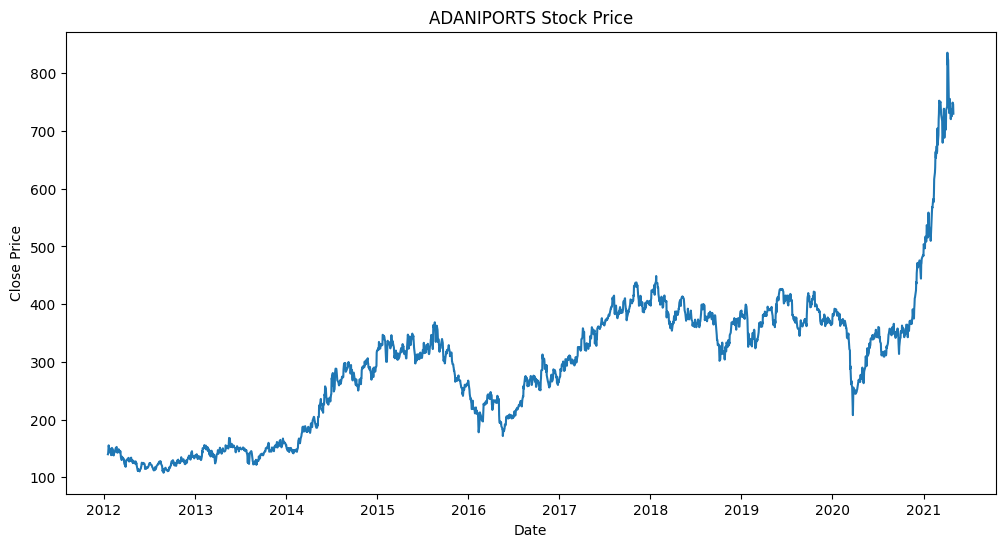

In [26]:
plt.figure(figsize=(12,6))
plt.plot(d['Date'], d['Close'])
plt.title(f'{stock_name} Stock Price')
plt.xlabel('Date')
plt.ylabel('Close Price')

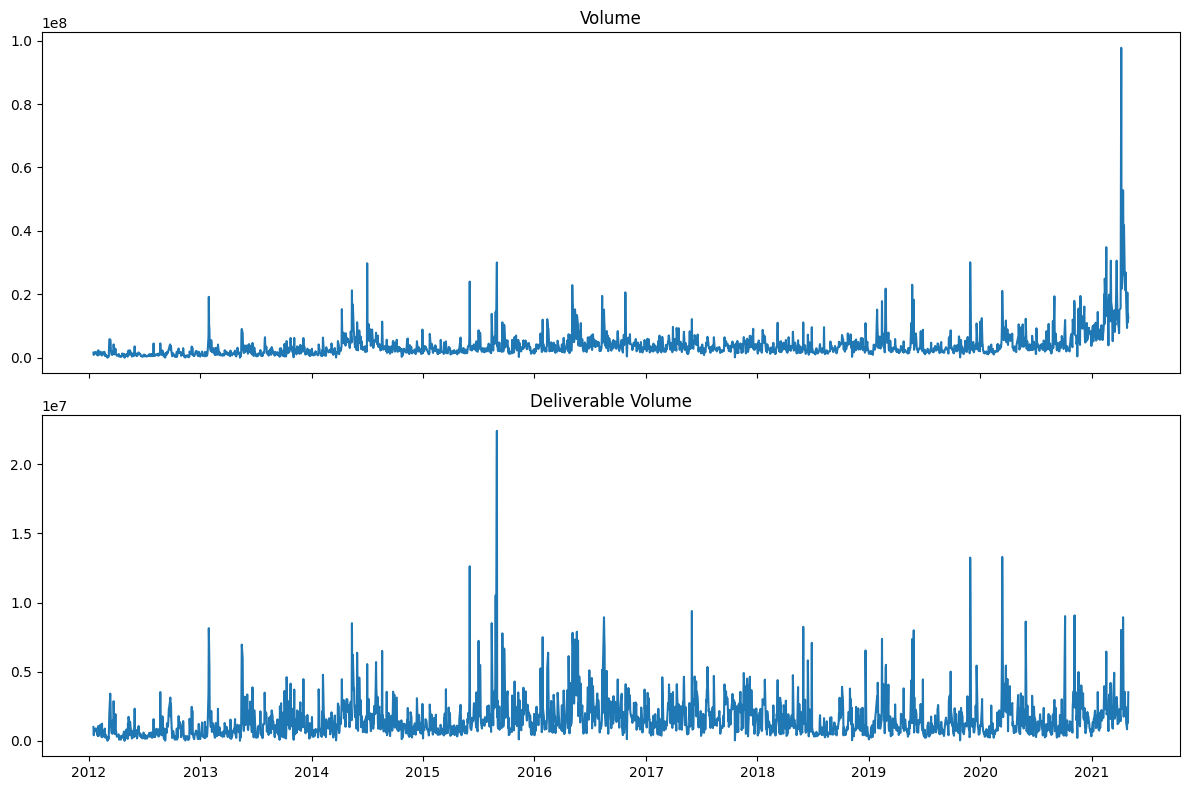

In [27]:
fig,ax = plt.subplots(2,1,figsize=(12,8),sharex = True)

ax[0].plot(d['Date'],d['Volume'])
ax[0].set_title('Volume')


ax[1].plot(d['Date'],d['Deliverable Volume'])
ax[1].set_title('Deliverable Volume')

plt.tight_layout()  #automatic adjust graphs,spacing between axes and graphs
plt.show()

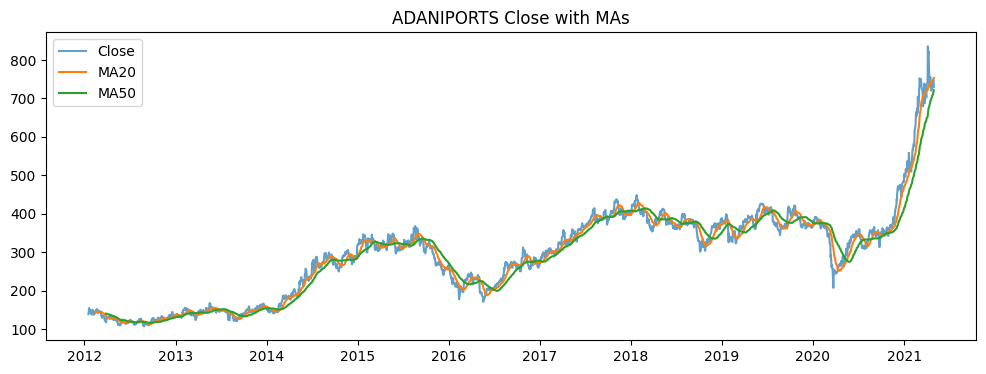

In [28]:
d['MA20'] = d['Close'].rolling(20).mean()
d['MA50'] = d['Close'].rolling(50).mean()
plt.figure(figsize=(12,4))
plt.plot(d['Date'], d['Close'], label='Close', alpha=0.7)
plt.plot(d['Date'], d['MA20'], label='MA20')
plt.plot(d['Date'], d['MA50'], label='MA50')
plt.legend(); plt.title(f'{stock_name} Close with MAs'); plt.show()

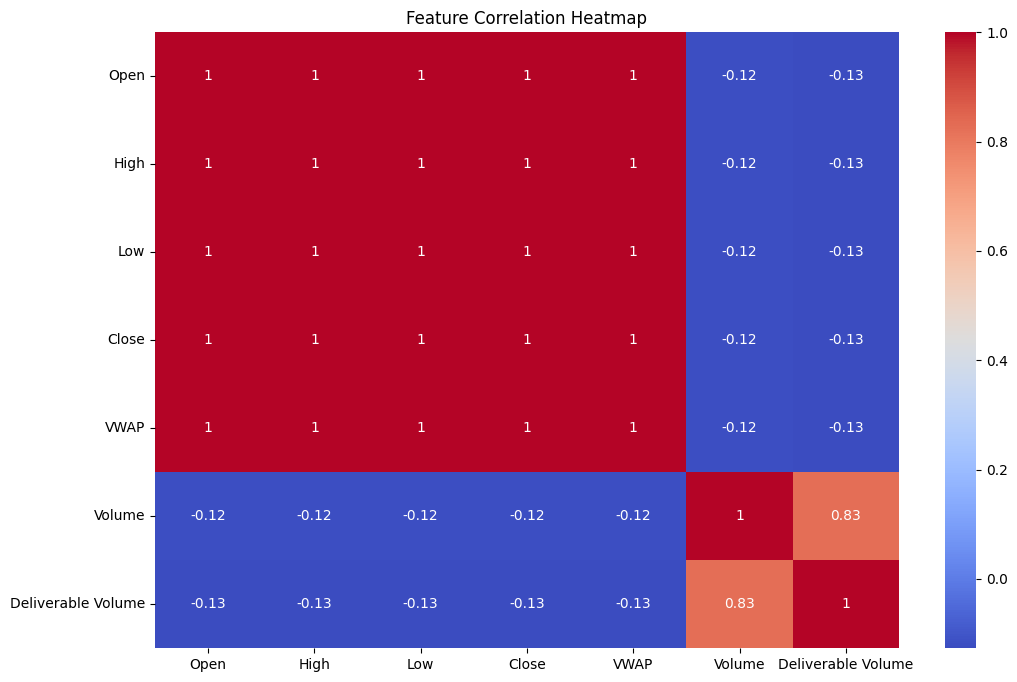

In [29]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True,cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [30]:
import pickle

pickle.dump(df, open('/content/drive/MyDrive/df_clean.pkl', 'wb'))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/df_clean.pkl'

In [ ]:
df.head()

,Date,Symbol,Open,High,Low,Close,VWAP,Volume,Deliverable Volume
1023,2012-01-17,ADANIPORTS,137.1,141.00,135.00,140.00,138.13,1636196,1004327.0
1024,2012-01-18,ADANIPORTS,142.0,143.80,138.70,141.70,141.25,890591,404925.0
1025,2012-01-19,ADANIPORTS,144.0,150.55,143.15,149.40,146.72,1456077,721545.0
1026,2012-01-20,ADANIPORTS,151.9,157.60,150.25,155.40,153.76,1634070,861145.0
1027,2012-01-23,ADANIPORTS,155.4,155.40,145.10,146.75,149.54,1657609,820653.0
